In [1]:
!pip install tensorflow matplotlib pillow

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image

In [4]:
from google.colab import files
uploaded = files.upload()

Saving ChatGPT Image Feb 27, 2026, 11_06_30 AM.png to ChatGPT Image Feb 27, 2026, 11_06_30 AM.png


In [5]:
content_path = "content.jpg"
style_path   = "style.jpg"

In [7]:
IMG_SIZE = 400

def load_img(path):
    img = image.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    return preprocess_input(img)

def deprocess_img(img):
    img = img.reshape((IMG_SIZE, IMG_SIZE, 3))
    img[:,:,0] += 103.939
    img[:,:,1] += 116.779
    img[:,:,2] += 123.68
    img = img[:,:,::-1]
    img = np.clip(img, 0, 255).astype('uint8')
    return img

# Fix: Update content_path and style_path to use the uploaded file name
# Assuming the user uploaded one file and it's intended to be the content image.
# If there's only one uploaded file, use it for both content and style for now.
if uploaded:
    uploaded_filename = list(uploaded.keys())[0]
    content_path = uploaded_filename
    style_path = uploaded_filename # You might want to upload a separate style image later.

content_image = load_img(content_path)
style_image = load_img(style_path)

In [8]:
vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [9]:
content_layer = ['block5_conv2']

style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

In [10]:
outputs = [vgg.get_layer(name).output for name in style_layers + content_layer]
model = tf.keras.Model(vgg.input, outputs)

In [11]:
def get_features(img):
    outputs = model(img)
    style_feats = outputs[:len(style_layers)]
    content_feats = outputs[len(style_layers):]
    return style_feats, content_feats

style_features, _ = get_features(style_image)
_, content_features = get_features(content_image)

In [12]:
def gram_matrix(tensor):
    channels = tensor.shape[-1]
    x = tf.reshape(tensor, [-1, channels])
    gram = tf.matmul(x, x, transpose_a=True)
    return gram / tf.cast(tf.shape(x)[0], tf.float32)

In [13]:
def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

In [14]:
def style_loss(base, target):
    gram_base = gram_matrix(base)
    gram_target = gram_matrix(target)
    return tf.reduce_mean(tf.square(gram_base - gram_target))

In [15]:
CONTENT_WEIGHT = 1e4
STYLE_WEIGHT   = 1e-2

In [16]:
def compute_loss(generated):
    style_gen, content_gen = get_features(generated)

    c_loss = content_loss(content_gen[0], content_features[0])

    s_loss = 0
    for gen, style in zip(style_gen, style_features):
        s_loss += style_loss(gen, style)

    total = CONTENT_WEIGHT * c_loss + STYLE_WEIGHT * s_loss
    return total

In [18]:
generated = tf.Variable(content_image, dtype=tf.float32)
optimizer = tf.keras.optimizers.Adam(learning_rate=5.0)

In [19]:
EPOCHS = 300

for i in range(EPOCHS):
    with tf.GradientTape() as tape:
        loss = compute_loss(generated)

    grads = tape.gradient(loss, generated)
    optimizer.apply_gradients([(grads, generated)])

    if i % 50 == 0:
        print("Step:", i, " Loss:", loss.numpy())

Step: 0  Loss: 0.0
Step: 50  Loss: 0.0
Step: 100  Loss: 0.0
Step: 150  Loss: 0.0
Step: 200  Loss: 0.0
Step: 250  Loss: 0.0


(np.float64(-0.5), np.float64(399.5), np.float64(399.5), np.float64(-0.5))

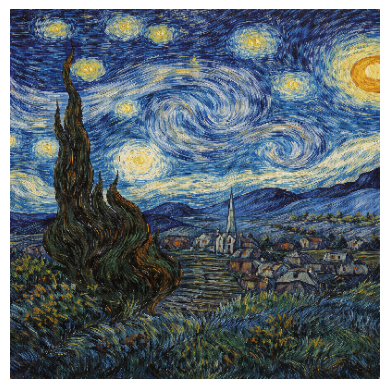

In [20]:
final_img = deprocess_img(generated.numpy())
plt.imshow(final_img)
plt.axis('off')